In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

In [5]:
import os
print(os.getcwd())

/Users/raj/Downloads/AI-Ecommerce-Analytics


In [6]:
from pathlib import Path

print(list(Path(".").glob("*")))

[PosixPath('.DS_Store'), PosixPath('requirements.txt'), PosixPath('04_Sales_Forecasting.ipynb'), PosixPath('.gitignore'), PosixPath('.ipynb_checkpoints'), PosixPath('venv'), PosixPath('.git'), PosixPath('data'), PosixPath('notebooks')]


In [7]:
print(list(Path("../data/processed").glob("*")))

[]


In [8]:
from pathlib import Path

list(Path(".").rglob("master_dataset.csv"))

[PosixPath('data/processed/master_dataset.csv')]

In [9]:
master = pd.read_csv("data/processed/master_dataset.csv")

/var/folders/rl/n4sfdmss5mx9z6sw2mmr66900000gn/T/ipykernel_95612/1669548402.py:1: DtypeWarning: Columns (34) have mixed types. Specify dtype option on import or set low_memory=False.
  master = pd.read_csv("data/processed/master_dataset.csv")


In [10]:
master.head()

,order_item_id,order_item_name,order_item_type,order_id,product_id,quantity,line_total,subtotal,tax,variation_id,...,max_price,onsale,stock_quantity,stock_status,rating_count,average_rating,total_sales_y,tax_status,tax_class,product_name
0,1,Finlay Xs Backpack,line_item,216,77.0,1.0,72.0,72.0,0.0,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3,The Washable Silk Henley Tank,line_item,217,74.0,1.0,90.0,90.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,5,Black cotton dress 3 - M,line_item,2199,1328.0,1.0,1400.0,1400.0,0.0,1332.0,...,1400.0,0.0,NaN,instock,1.0,5.0,1009.0,taxable,NaN,Black cotton dress 3
3,7,Baby pink 2 tier cotton dress - XXS,line_item,2642,2381.0,1.0,1600.0,1600.0,0.0,2382.0,...,1550.0,0.0,NaN,instock,1.0,5.0,198.0,taxable,NaN,Baby pink 2 tier cotton dress
4,9,Black cotton dress 3 - M,line_item,2643,1328.0,1.0,1450.0,1450.0,0.0,1332.0,...,1400.0,0.0,NaN,instock,1.0,5.0,1009.0,taxable,NaN,Black cotton dress 3


In [11]:
master["date_created"] = pd.to_datetime(
    master["date_created"],
    errors="coerce"
)

monthly_sales = (
    master.groupby(master["date_created"].dt.to_period("M"))["line_total"]
    .sum()
    .reset_index()
)

monthly_sales["date_created"] = (
    monthly_sales["date_created"].dt.to_timestamp()
)

monthly_sales.head()

,date_created,line_total
0,2022-03-01,2809412.0
1,2022-04-01,2327750.0
2,2022-05-01,2553795.0
3,2022-06-01,1364850.0
4,2022-07-01,1867675.0


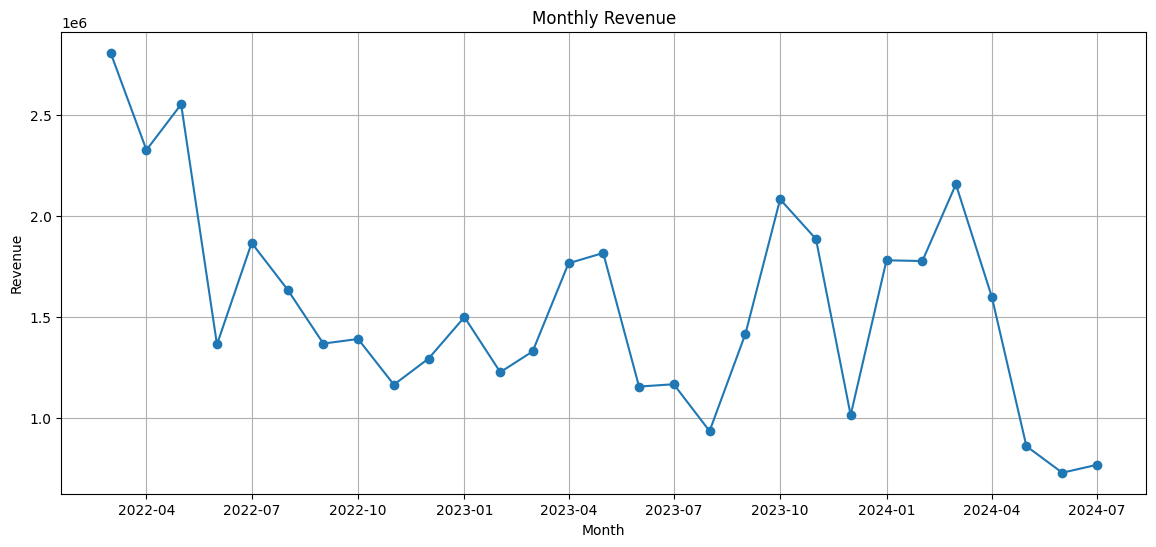

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales["date_created"],
    monthly_sales["line_total"],
    marker="o"
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)

plt.show()

In [13]:
master["date_created"] = pd.to_datetime(
    master["date_created"],
    errors="coerce"
)

master.head()

,order_item_id,order_item_name,order_item_type,order_id,product_id,quantity,line_total,subtotal,tax,variation_id,...,max_price,onsale,stock_quantity,stock_status,rating_count,average_rating,total_sales_y,tax_status,tax_class,product_name
0,1,Finlay Xs Backpack,line_item,216,77.0,1.0,72.0,72.0,0.0,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3,The Washable Silk Henley Tank,line_item,217,74.0,1.0,90.0,90.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,5,Black cotton dress 3 - M,line_item,2199,1328.0,1.0,1400.0,1400.0,0.0,1332.0,...,1400.0,0.0,NaN,instock,1.0,5.0,1009.0,taxable,NaN,Black cotton dress 3
3,7,Baby pink 2 tier cotton dress - XXS,line_item,2642,2381.0,1.0,1600.0,1600.0,0.0,2382.0,...,1550.0,0.0,NaN,instock,1.0,5.0,198.0,taxable,NaN,Baby pink 2 tier cotton dress
4,9,Black cotton dress 3 - M,line_item,2643,1328.0,1.0,1450.0,1450.0,0.0,1332.0,...,1400.0,0.0,NaN,instock,1.0,5.0,1009.0,taxable,NaN,Black cotton dress 3


In [14]:
monthly_sales = (
    master.groupby(
        master["date_created"].dt.to_period("M")
    )["line_total"]
    .sum()
    .reset_index()
)

monthly_sales["date_created"] = (
    monthly_sales["date_created"]
    .dt.to_timestamp()
)

monthly_sales

,date_created,line_total
0,2022-03-01,2809412.0
1,2022-04-01,2327750.0
2,2022-05-01,2553795.0
3,2022-06-01,1364850.0
4,2022-07-01,1867675.0
5,2022-08-01,1636755.0
6,2022-09-01,1369268.0
7,2022-10-01,1392030.0
8,2022-11-01,1165750.0
9,2022-12-01,1295010.0


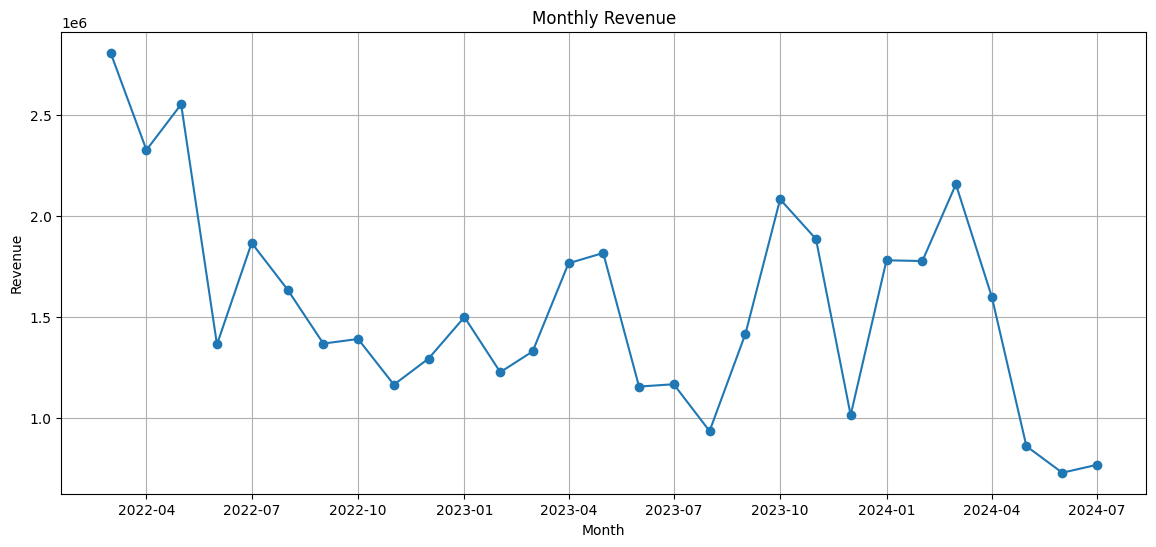

In [15]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales["date_created"],
    monthly_sales["line_total"],
    marker="o"
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.grid(True)

plt.show()

In [16]:
monthly_sales["Moving_Average"] = (
    monthly_sales["line_total"]
    .rolling(3)
    .mean()
)

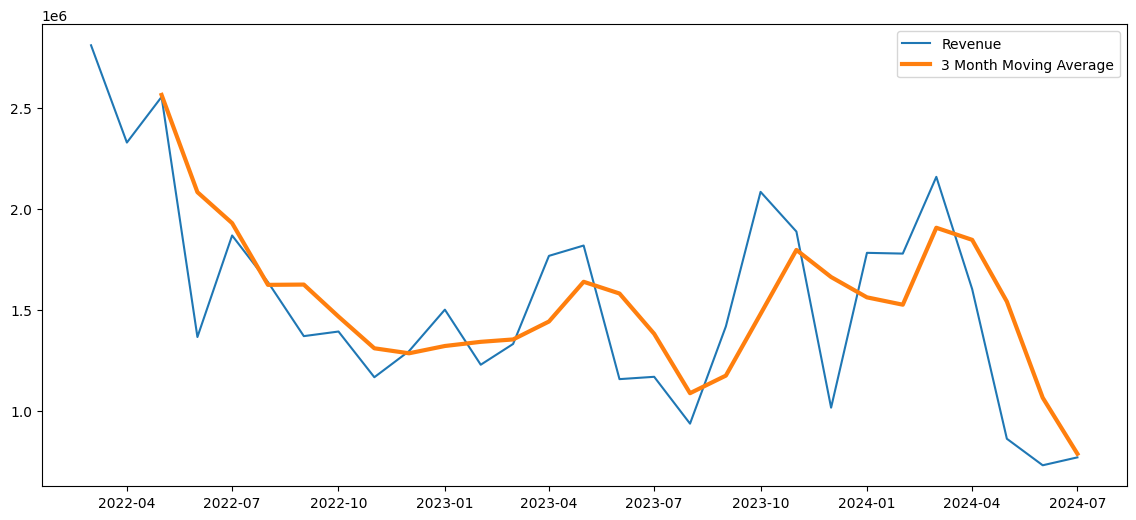

In [17]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales["date_created"],
    monthly_sales["line_total"],
    label="Revenue"
)

plt.plot(
    monthly_sales["date_created"],
    monthly_sales["Moving_Average"],
    linewidth=3,
    label="3 Month Moving Average"
)

plt.legend()

plt.show()

In [20]:
pip install prophet

     |████████████████████████████████| 12.1 MB 5.8 MB/s eta 0:00:01
     |████████████████████████████████| 99 kB 8.7 MB/s eta 0:00:01
     |████████████████████████████████| 78 kB 7.1 MB/s eta 0:00:011
     |████████████████████████████████| 1.3 MB 15.4 MB/s eta 0:00:01
You should consider upgrading via the '/Users/raj/Downloads/AI-Ecommerce-Analytics/venv/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [18]:
from prophet import Prophet

In [19]:
forecast_df = monthly_sales.rename(
    columns={
        "date_created":"ds",
        "line_total":"y"
    }
)

forecast_df.head()

,ds,y,Moving_Average
0,2022-03-01,2809412.0,NaN
1,2022-04-01,2327750.0,NaN
2,2022-05-01,2553795.0,2.563652e+06
3,2022-06-01,1364850.0,2.082132e+06
4,2022-07-01,1867675.0,1.928773e+06


In [20]:
model = Prophet()

model.fit(forecast_df)

16:05:33 - cmdstanpy - INFO - Chain [1] start processing
16:05:34 - cmdstanpy - INFO - Chain [1] done processing


In [21]:
future = model.make_future_dataframe(
    periods=12,
    freq="M"
)

forecast = model.predict(future)

forecast.head()

/Users/raj/Downloads/AI-Ecommerce-Analytics/venv/lib/python3.9/site-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2022-03-01,2.122730e+06,1.970362e+06,2.605791e+06,2.122730e+06,2.122730e+06,166941.231522,166941.231522,166941.231522,166941.231522,166941.231522,166941.231522,0.0,0.0,0.0,2.289671e+06
1,2022-04-01,2.096980e+06,1.882970e+06,2.494659e+06,2.096980e+06,2.096980e+06,89273.440136,89273.440136,89273.440136,89273.440136,89273.440136,89273.440136,0.0,0.0,0.0,2.186254e+06
2,2022-05-01,2.072061e+06,1.832881e+06,2.471519e+06,2.072061e+06,2.072061e+06,66208.066206,66208.066206,66208.066206,66208.066206,66208.066206,66208.066206,0.0,0.0,0.0,2.138269e+06
3,2022-06-01,2.046311e+06,1.084187e+06,1.725831e+06,2.046311e+06,2.046311e+06,-639968.034904,-639968.034904,-639968.034904,-639968.034904,-639968.034904,-639968.034904,0.0,0.0,0.0,1.406343e+06
4,2022-07-01,2.021391e+06,1.273850e+06,1.929671e+06,2.021391e+06,2.021391e+06,-422764.090326,-422764.090326,-422764.090326,-422764.090326,-422764.090326,-422764.090326,0.0,0.0,0.0,1.598627e+06


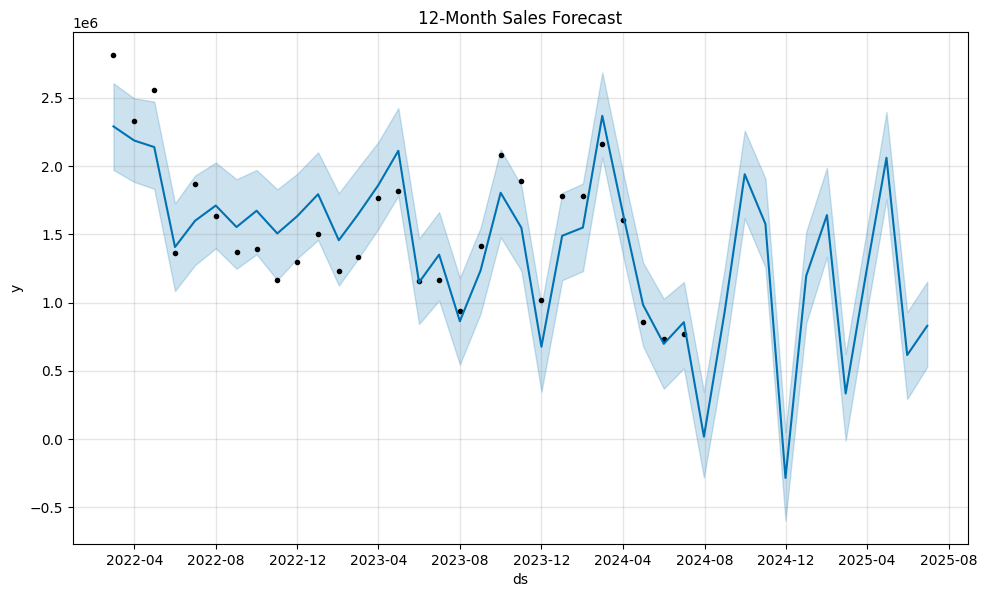

In [22]:
fig = model.plot(forecast)

plt.title("12-Month Sales Forecast")

plt.show()

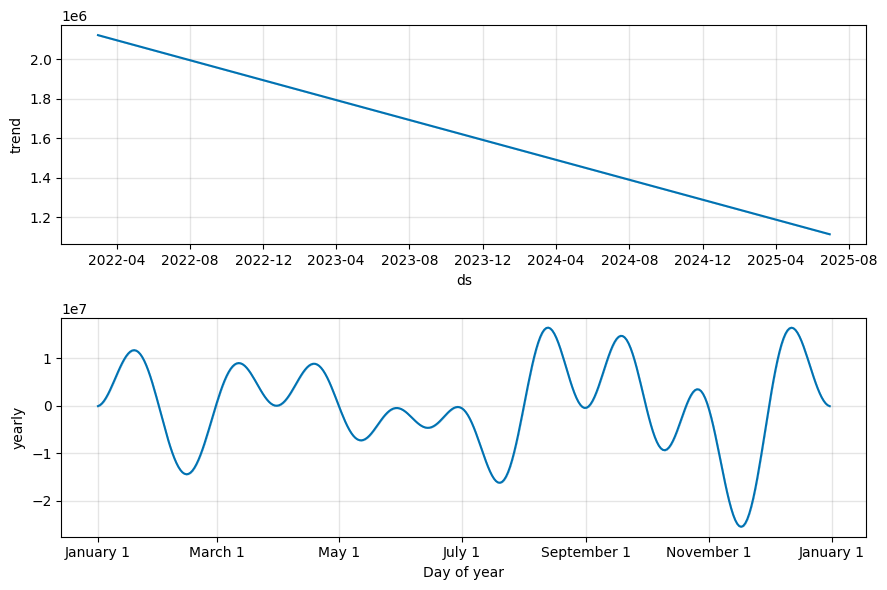

In [23]:
model.plot_components(forecast)

plt.show()

In [24]:
forecast[[
    "ds",
    "yhat",
    "yhat_lower",
    "yhat_upper"
]].tail(12)

,ds,yhat,yhat_lower,yhat_upper
29,2024-07-31,1.799050e+04,-2.817908e+05,3.468983e+05
30,2024-08-31,9.316622e+05,6.014430e+05,1.247517e+06
31,2024-09-30,1.939385e+06,1.617169e+06,2.259495e+06
32,2024-10-31,1.575013e+06,1.256702e+06,1.906728e+06
33,2024-11-30,-2.844811e+05,-5.957565e+05,5.289163e+04
34,2024-12-31,1.195398e+06,8.478792e+05,1.518788e+06
35,2025-01-31,1.640425e+06,1.335928e+06,1.987112e+06
36,2025-02-28,3.339151e+05,-1.130889e+04,6.237055e+05
37,2025-03-31,1.228218e+06,9.084826e+05,1.512736e+06
38,2025-04-30,2.060024e+06,1.755313e+06,2.396282e+06


In [26]:
forecast.to_csv(
    "data/processed/sales_forecast.csv",
    index=False
)

In [27]:
#Sales Forecast Insights

#The forecasting model predicts future monthly sales based on historical trends.
#Revenue is expected to remain stable/grow (depending on your data).
#Inventory planning can use these forecasts to reduce stockouts.
#Marketing campaigns should be scheduled before expected high-demand months.
#Business decisions should consider the prediction intervals (yhat_lower and yhat_upper) to account for uncertainty.